In [1]:
import os
import numpy as np

import darklim

from darklim.sensitivity._random_sampling import pdf_sampling

from scipy.special import factorial
import scipy.stats as stats
import scipy.special as special
from scipy import interpolate

import matplotlib.pyplot as plt
if None != os.getenv('NERSC_HOST'):
    import matplotlib.font_manager as font_manager
    font_manager.fontManager.addfont('/global/cfs/cdirs/lz/physics/WS/SR1/msttcorefonts/Times_New_Roman.ttf')

import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'

from multihist import Hist1d

%matplotlib inline

In [2]:
E_LOW_GLOBAL_KEV = 1e-6
E_HIGH_GLOBAL_KEV = 100.
NPTS_GLOBAL = int(1e5)

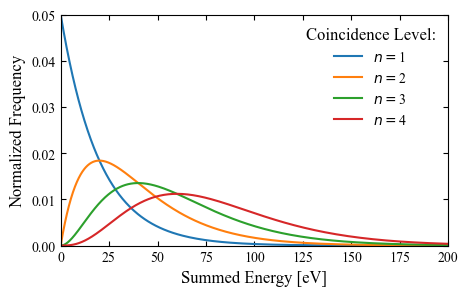

In [18]:
fig, ax = plt.subplots(1,figsize=(5,3))

lam = 1/20
ks = np.arange(1,5)
x = np.geomspace(1e-3,1e3,1000)

for k in ks:

    dist = stats.erlang.pdf(x,a=k,loc=0,scale=1/lam)
    dist2 = stats.expon.pdf(x,loc=0,scale=1/lam)

    plt.plot(x, dist,label=r'$n=$'+'{:d}'.format(k))
    
#plt.plot(x, dist2,'r--',label='Expo. Dist')
ax.set_xlim(0,200)
ax.set_ylim(0,0.05)
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend(loc='upper right',frameon=False,title='Coincidence Level:',title_fontsize=12)
ax.set_xlabel('Summed Energy [eV]',fontsize=12)
ax.set_ylabel('Normalized Frequency',fontsize=12)

plt.savefig('./pretty_plots/erlang.png',facecolor='white',bbox_inches='tight')

In [8]:
def power_bkgd(x,amplitude,abs_power):
    return amplitude * x**(-1*abs_power)
pdf = lambda x: power_bkgd(x,1.4e-8, 5.77)+power_bkgd(x,0.107, 2.72)

en_interp = np.geomspace(1.865e-3,10, num=10000)
rate = np.trapz( pdf(en_interp), x=en_interp)
print('{:0.1f} cts/day'.format(rate))

33731.1 cts/day


In [18]:
# generate ntoys

def power_bkgd(x,amplitude,abs_power):
    return amplitude * x**(-1*abs_power)
pdf = lambda x: power_bkgd(x,1.4e-8, 5.77)+power_bkgd(x,0.107, 2.72)

def pdf_integral(pdf,e_low,e_high,npts):
    '''
    assumes 'pdf' is a lambda function
    '''
    en_interp = np.geomspace(e_low,e_high, num=npts)
    return np.trapz( pdf(en_interp), x=en_interp)

w = 100e-6 # coincidence window in seconds

energy_res = 0.373e-3 # energy resolution in keV
nsigma = 5
threshold = nsigma*energy_res

e_low = 0.5e-3 #keV - determined by lowest per device threshold considered
e_high = 2 #keV
npts = 100000

print('threshold = {:0.3e} keV'.format(threshold))
print('threshold = {:0.3e} eV'.format(threshold*1000))



threshold = 1.865e-03 keV
threshold = 1.865e+00 eV


In [6]:

#print('integral from {} to {} keV = {:.2e} evts/day'.format(bins[0],bins[-1],integral))
#print('= {:0.2e} evts/s'.format(integral/24/3600))

In [27]:
# generate toys from m devices with n-fold coincidence

save = False
show_plot = False

show_sample_plot = False

var_threshold = True
per_device_threshold = 0.
#devices = np.array([1,2,3,4])

ntoys = 1000000
devices = np.array([1,2])

res_dict = {}

for i,m in enumerate(devices): # loop over total number of devices

    if m<3:
        ntoys = int(1e7)
    else:
        ntoys = int(1e8)
        
    if show_plot:
        fig, ax = plt.subplots(1,figsize=(8,5))
    print('')
    print('Considering',m,'total devices')
    # simulate events in all devices:
    evts = np.zeros((m,ntoys))
    for d in range(m): # simulate ntoys in each device
        evts[d,:] = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )

    if show_sample_plot:
        fig, ax = plt.subplots(1,figsize=(6,4))
        h = Hist1d(evts[0,:],bins=np.geomspace(e_low,e_high,num=500))
        bw = h.bin_edges[1::]-h.bin_edges[:-1]
        h *= 1/np.sum(h.histogram)
        h *= 1/bw
        h.plot(lw=1,label='{}-fold'.format(c))
        plt.plot(h.bin_centers,pdf(h.bin_centers)*(1/pdf_integral(pdf,e_low,e_high,npts)),lw=1,color='red', label='Run 47 Power-Law\nLEE Model')
        ax.set_xlim(e_low*0.5,e_high)
        ax.set_xscale('log')
        ax.set_yscale('log')

        
    summed_energy = np.sum(evts,axis=0) # total energy in all devices
    
    # consider coincidence levels from 1 to number of devices
    coinc = np.arange(1,m+1)
    for c in coinc:
        print('Coincidence level =',c)
        if var_threshold:
            nsigma = stats.norm.isf(stats.norm.sf(5)**(1/c))
        else:
            nsigma = 5
        per_device_threshold = nsigma * energy_res
        threshold = c*per_device_threshold

        print('/tThreshold is {:0.2f} sigma = {:0.3f} eV in each device'.format(nsigma,per_device_threshold*1000))
        print('/t Total energy threshold = {:0.3f} eV'.format(threshold*1000))

        evts[np.where(evts<per_device_threshold)] = 0 # sets events below threshold to zero - this should be the *per device threshold*
        n_over = np.count_nonzero(evts,axis=0) # gives number of devices above threshold for each event        
        keepers = summed_energy[n_over>=c] # summed energy of evts which satisfy coincidence requirement
        print('{:0.3f}% of evts survive coincidence requirement'.format(100.*len(keepers)/ntoys))
        
        # get rate above device threshold in single device:
        rate = pdf_integral(pdf,per_device_threshold,e_high,npts)/24/3600 # want in counts/s/kg
        print('Rate from {:.4f} to {:.4f} keV = {:.2e} evts/d/kg'.format(per_device_threshold,e_high,rate*3600*24))
        
        # pileup rate:
        term1 = special.factorial(m)/special.factorial(m-c)
        term2 = rate**c * w**(c-1)
        pile_up_rate = term1*term2*3600*24
        print('{}-fold pileup rate = {:.2e} evts/d/kg'.format(c,pile_up_rate))
                
        res_dict[str(m)+'_'+str(c)+'_summede'] = keepers
        res_dict[str(m)+'_'+str(c)+'_rate'] = pile_up_rate
        
        if show_plot:
            h = Hist1d(keepers,bins=npts,range=(e_low,e_high))
            bw = h.bin_centers[1]-h.bin_centers[0]

            #normalize:
            h *= pile_up_rate/np.sum(h.histogram)
            h *= 1/bw

            res_dict[str(m)+'_'+str(c)+'_h'] = h
            
            h.plot(lw=1,label='{}-fold'.format(c))

            ax.set_title('{:d} Total Devices'.format(m))
            #ax.set_xlim(e_low,e_high)
            ax.set_xlim(e_low,0.05)
            ax.set_xscale('log')
            #ax.set_ylim(1,None)
            ax.set_yscale('log')
            ax.legend(loc='upper right', title='Coincidence Level:', frameon=False,ncol=1)
            #ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
            ax.set_xlabel('Summed Energy [keV]')
            ax.set_ylabel('Rate [cts/d/kg/keV]')

            print('hist rate check: {}'.format( np.sum(h.histogram) ))

            if save:
                outname = './LEE_templates/LEE_bkg_{:d}device_{:d}fold_{:0.0f}mus.txt'.format(m,c,w/1e-6)
                tot = np.column_stack( (h.bin_centers, h.histogram) )
                np.savetxt(outname,tot,fmt=['%.5e','%0.5e'] ,delimiter=' ', header='energy[keV] evts/day/keV/kg')
    
print('done.')# generate toys from m devices with n-fold coincidence


Considering 1 total devices
Coincidence level = 1
/tThreshold is 5.00 sigma = 1.865 eV in each device
/t Total energy threshold = 1.865 eV
0.206% of evts survive coincidence requirement
Rate from 0.0019 to 2.0000 keV = 3.37e+04 evts/d/kg
1-fold pileup rate = 3.37e+04 evts/d/kg

Considering 2 total devices
Coincidence level = 1
/tThreshold is 5.00 sigma = 1.865 eV in each device
/t Total energy threshold = 1.865 eV
0.410% of evts survive coincidence requirement
Rate from 0.0019 to 2.0000 keV = 3.37e+04 evts/d/kg
1-fold pileup rate = 6.75e+04 evts/d/kg
Coincidence level = 2
/tThreshold is 3.27 sigma = 1.220 eV in each device
/t Total energy threshold = 2.440 eV
0.000% of evts survive coincidence requirement
Rate from 0.0012 to 2.0000 keV = 2.38e+05 evts/d/kg
2-fold pileup rate = 1.31e+02 evts/d/kg
done.


1-device, 1-fold hist rate check: 8.81e+08 cts/d
2-device, 1-fold hist rate check: 1.37e+09 cts/d
2-device, 2-fold hist rate check: 1.70e+06 cts/d
done.


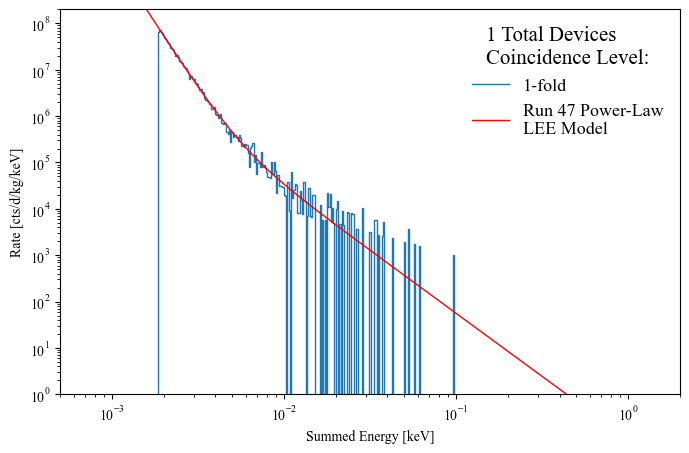

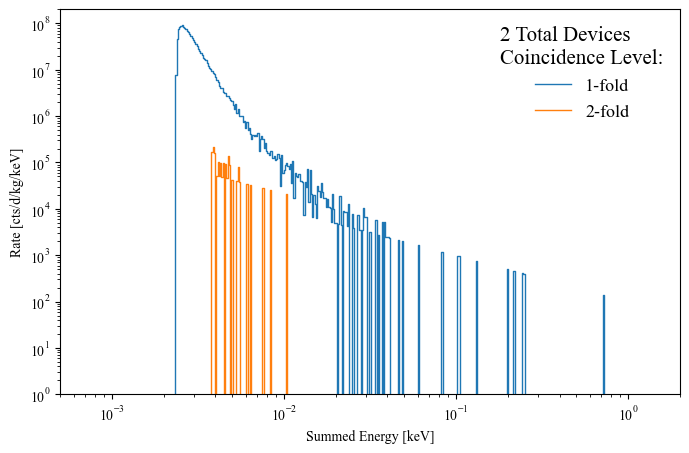

In [28]:
# plot results separately so we can play with binning
save = False

for i,m in enumerate(devices):
    fig, ax = plt.subplots(1,figsize=(8,5))
    coinc = np.arange(1,m+1)
    for c in coinc:

        sum_energy = res_dict[str(m)+'_'+str(c)+'_summede']

        # log bins
        h = Hist1d(sum_energy,bins=np.geomspace(e_low,e_high,num=500))
        bw = h.bin_edges[1::]-h.bin_edges[:-1]

        #h = Hist1d(sum_energy,bins=npts,range=(e_low,e_high))
        #bw = h.bin_centers[1]-h.bin_centers[0]

        #normalize:
        pile_up_rate = res_dict[str(m)+'_'+str(c)+'_rate']
        h *= pile_up_rate/np.sum(h.histogram)
        h *= 1/bw
        
        
        h.plot(lw=1,label='{}-fold'.format(c))
        #h.plot(scale_histogram_by=1,lw=1,label='{}-fold'.format(c),normed=True)
        #h.plot(scale_histogram_by=1/bw,lw=1,label='{}-fold MC w/threshold'.format(c),normed=True)

        if m==1 and c==1: #overlay pdf in this case
            plt.plot(h.bin_centers,pdf(h.bin_centers),lw=1,color='red', label='Run 47 Power-Law\nLEE Model')
        
        #x = np.geomspace(e_low,e_high,10000)
        #dist = pdf(x)
        #plt.plot(x, dist/np.trapz(dist, x=x),label='Summed Power Law')

        #ax.set_title('{:d} Total Devices'.format(m))
        #ax.set_xlim(e_low,e_high)
        ax.set_xlim(e_low,e_high)
        ax.set_xscale('log')
        ax.set_ylim(1,2e8)
        ax.set_yscale('log')
        ax.legend(loc='upper right', title='{:d} Total Devices\nCoincidence Level:'.format(m), frameon=False,ncol=1,fontsize=13,title_fontsize=15)
        #ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
        ax.set_xlabel('Summed Energy [keV]')
        ax.set_ylabel('Rate [cts/d/kg/keV]')

        print('{}-device, {}-fold hist rate check: {:0.2e} cts/d'.format(m,c, np.sum(h.histogram) ))

        if save:
            outname = './LEE_templates/LEE_bkg_{:d}device_{:d}fold_{:0.0f}mus.txt'.format(m,c,w/1e-6)
            tot = np.column_stack( (h.bin_centers, h.histogram) )
            np.savetxt(outname,tot,fmt=['%.5e','%0.5e'] ,delimiter=' ', header='energy[keV] evts/day/keV/kg')

print('done.')# generate toys from m devices with n-fold coincidence

In [18]:
h.bin_edges

array([1.00000000e-03, 1.04999000e-03, 1.09998000e-03, ...,
       4.99990002e+00, 4.99995001e+00, 5.00000000e+00])

In [19]:
h.bin_edges[1::]

array([1.04999000e-03, 1.09998000e-03, 1.14997000e-03, ...,
       4.99990002e+00, 4.99995001e+00, 5.00000000e+00])

In [20]:
h.bin_edges[:-1]

array([1.00000000e-03, 1.04999000e-03, 1.09998000e-03, ...,
       4.99985003e+00, 4.99990002e+00, 4.99995001e+00])

In [21]:
h.bin_edges[1::]-h.bin_edges[:-1]

array([4.999e-05, 4.999e-05, 4.999e-05, ..., 4.999e-05, 4.999e-05,
       4.999e-05])

In [15]:
print(bw)

4.999000000000019e-05


In [6]:
keepers.max()

0.011623914633628048

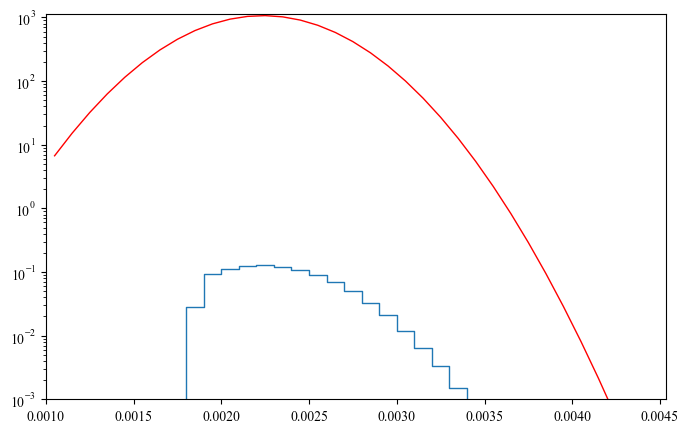

In [39]:
# save dummy data to test loading and interpolation inside SensEst:
save = False

mu = 6*energy_res
sigma = energy_res
s = np.random.normal(mu, sigma, 1000000)
pts = s[s>threshold]

fig, ax = plt.subplots(1,figsize=(8,5))
h = Hist1d(pts,bins=npts,range=(e_low,e_high))
bw = h.bin_centers[1]-h.bin_centers[0]
h = h*(1/bw)
#h.plot(scale_histogram_by=1,lw=1,normed=True)
#h.plot(scale_histogram_by=1/bw,lw=1,normed=True)
h.plot(lw=1,normed=True)

bins = h.bin_centers
vals = h.histogram

plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi))*np.exp(-(bins - mu)**2 / (2 * sigma**2) ),lw=1, color='r')

ax.set_xlim(e_low,pts.max()*1.1)
#ax.set_xscale('log')
ax.set_ylim(0.001,None)
ax.set_yscale('log')

if save:
        #outname = 'LEE_bkg_{:d}device_{:d}fold_{:0.0f}mus.txt'.format(n_devices,n,window/1e-6)
        outname = 'testdata.txt'
        tot = np.column_stack( (bins, vals) )
        np.savetxt(outname,tot,fmt=['%.5e','%0.5e'] ,delimiter=' ', header='energy[keV] evts/day/keV')

In [43]:
# load testdata and make interp func:
testin = np.loadtxt('testdata.txt',skiprows=1)
print(np.shape(testin))

print(type(testin))

(100000, 2)
<class 'numpy.ndarray'>


In [ ]:
interp_func = interpolate.interp1d(testin[:,0],testin[:,1])

fig, ax = plt.subplots(1,figsize=(8,5))

In [21]:
# generate toys from m devices with n-fold coincidence

sum_all_energy = False

devices = np.array([1,2,3,4])

summed_energy = {}

for i,m in enumerate(devices): # loop over total number of devices
    print('device #',m')
    # simulate events in all devices:
    evts = np.zeros((m,ntoys))
    for d in range(m): # simulate ntoys in each device
        evts[d,:] = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )
    
    #print( evts[0,:10] )
    evts[np.where(evts<threshold)] = 0 # sets events below threshold to zero - this should be the *per device threshold*
    #print( evts[0,:10] )
    summed_energy[m] = np.sum(evts,axis=0) # sum energy accross devices
    
    #coinc = np.arange(2,m+1)
    #print('{} devices. coinc levels considered are '.format(m),coinc)
    
    #for j,n in enumerate(coinc):
    #    print('coinc level is ',n)
    #    
    #    # apply threshold to the first n channels
    #    for d in range(n):
    #        evts[d,:]
print('done.')

[0.00890226 0.00193366 0.01079027 0.00163338 0.00467823 0.00907259
 0.00135301 0.00893067 0.00977215 0.00495709]
[0.00890226 0.00193366 0.01079027 0.         0.00467823 0.00907259
 0.         0.00893067 0.00977215 0.00495709]
[0.0028602  0.00841154 0.00671738 0.00380692 0.00989576 0.00402931
 0.01010037 0.00149107 0.00516816 0.00806071]
[0.0028602  0.00841154 0.00671738 0.00380692 0.00989576 0.00402931
 0.01010037 0.         0.00516816 0.00806071]
[0.0034989  0.007528   0.00916924 0.00358474 0.00168518 0.00645742
 0.00662174 0.00107128 0.00932454 0.00543961]
[0.0034989  0.007528   0.00916924 0.00358474 0.         0.00645742
 0.00662174 0.         0.00932454 0.00543961]
[0.01026771 0.00553212 0.00389359 0.00553916 0.01084236 0.00924688
 0.00944472 0.00727594 0.00176651 0.00539641]
[0.01026771 0.00553212 0.00389359 0.00553916 0.01084236 0.00924688
 0.00944472 0.00727594 0.         0.00539641]
done.


Text(0.5, 0, 'Summed Energy [keV]')

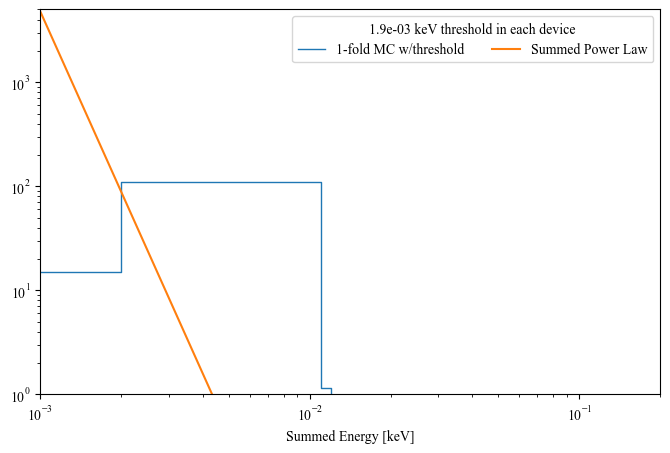

In [20]:
# histogram the simulated toys with PDF for single device
fig, ax = plt.subplots(1,figsize=(8,5))

m=1
h = Hist1d(summed_energy[m],bins=10000,range=(e_low,e_high))
bw = h.bin_centers[1]-h.bin_centers[0]
h.plot(scale_histogram_by=1/bw,lw=1,label='{}-fold MC w/threshold'.format(m),normed=True)

x = np.geomspace(e_low,e_high,10000)
#x = np.linspace(e_low,e_high,10000)

dist = pdf(x)
plt.plot(x, dist/np.trapz(dist, x=x),label='Summed Power Law')
        

ax.set_xlim(e_low,0.2)
ax.set_xscale('log')
ax.set_ylim(1,None)
ax.set_yscale('log')
ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.set_xlabel('Summed Energy [keV]')

1
2
3
4


Text(0.5, 0, 'Summed Energy [keV]')

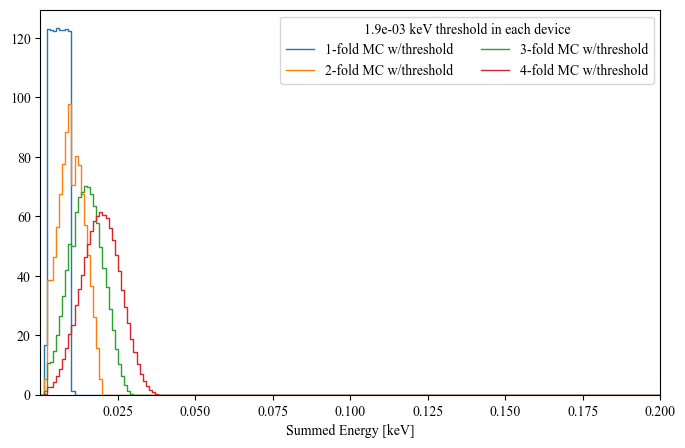

In [13]:
# histogram the simulated toys
fig, ax = plt.subplots(1,figsize=(8,5))

for i,m in enumerate(devices):
    h = Hist1d(summed_energy[m],bins=10000,range=(e_low,e_high))
    bw = h.bin_centers[1]-h.bin_centers[0]
    h.plot(scale_histogram_by=1/bw,lw=1,label='{}-fold MC w/threshold'.format(m),normed=True)

#x = np.geomspace(e_low,e_high,10000)
#x = np.linspace(e_low,e_high,10000)
#for k in devices:
#    dist = stats.erlang.pdf(x,a=k,loc=0,scale=1/lam)
#    plt.plot(x, dist/np.trapz(dist, x=x),label='Erlang, k={:d}'.format(k))
        

ax.set_xlim(e_low,0.2)
#ax.set_xscale('log')
ax.set_ylim(0,None)
ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.set_xlabel('Summed Energy [keV]')

In [25]:
test = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )
print(test)
test[np.where(test<0.02)] = 0
print(test)

[0.01814909 0.08861029 0.02425482 ... 0.00364906 0.00120441 0.01921873]
[0.         0.08861029 0.02425482 ... 0.         0.         0.        ]


In [24]:
test

array([0.06928629, 0.        , 0.        , ..., 0.        , 0.        ,
       0.        ])

10000


Text(0.5, 0, 'Summed Energy [keV]')

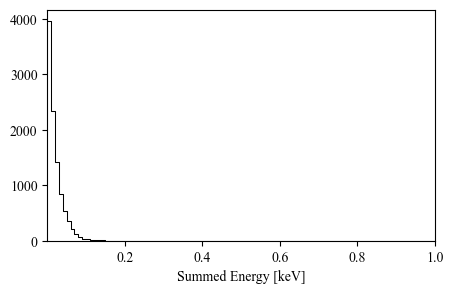

In [6]:
# histogram the simulated toys
fig, ax = plt.subplots(1,figsize=(5,3))

h = Hist1d(evts_sim,bins=npts,range=(e_low,e_high))
h.plot(color='black',lw=0.75)

print(h.n)

ax.set_xlim(e_low,1)
#ax.set_xscale('log')
ax.set_ylim(0,None)
#ax.legend(loc='upper right')
ax.set_xlabel('Summed Energy [keV]')

In [4]:
# Detector info setup

#n_devices = 4
#coinc = 2
#window = 100e-6 # s

mass_det = 0.00115 # mass in kg
time_elapsed = 1000 # days
efficiency = 1.0

tm = 'He' # target name

energy_res = 0.373e-3 # energy resolution in keV
#threshold = coinc*5*energy_res

print('detector mass is {} kg = {} g'.format(mass_det,mass_det*1000))
print('run time is {} days'.format(time_elapsed))
print('exposure is {} kg-days'.format(mass_det*time_elapsed))
#print('threshold = {:0.3f} eV'.format(threshold*1000))
#print('assuming {:d}-fold coincidence amongst {:d} devices in a {:0.1f} microsecond window'.format(coinc,n_devices,window/1e-6))

detector mass is 0.00115 kg = 1.15 g
run time is 1000 days
exposure is 1.15 kg-days


In [ ]:
SE = darklim.sensitivity.SensEst(mass_det, time_elapsed, eff=efficiency, tm=tm)

SE.reset_sim()
#SE.add_flat_bkgd(1) # flat background of 1 DRU
#SE.add_nfold_lee_bkgd(m=4,n=2,w=window)
SE.add_nfold_lee_bkgd(m=n_devices,n=coinc,w=window)

In [ ]:
# test the nfold LEE function

fig, ax = plt.subplots(1,figsize=(6,4))

save = False

#bins = np.linspace(0.0001,1,1000)
bins = np.geomspace(1e-3,1,1000)

n_devices = 1
#coinc = np.arange(1,5)
coinc = np.array([1])
window = 100e-6# s
for n in coinc:
    
    print('{}-fold coincidence:'.format(n))
    model = darklim.sensitivity.n_fold_lee(bins,m=n_devices,n=n,w=window)
    
    integral = np.trapz(model,x=bins)
    print('integral from {} to {} keV = {:.2e} evts/day'.format(bins[0],bins[-1],integral))
    print('= {:0.2e} evts/s'.format(integral/24/3600))
    print(' ')
    
    plt.plot(bins,model,label='{:d}-fold'.format(n))
    
    if save:
        outname = 'LEE_bkg_{:d}device_{:d}fold_{:0.0f}mus.txt'.format(n_devices,n,window/1e-6)
        tot = np.column_stack( (bins, model) )
        np.savetxt(outname,tot,fmt=['%.5e','%0.5e'] ,delimiter=' ', header='energy[keV] evts/day/keV')
    
#lhe_mass = 0.010 # kg
#ax.axhline(1*lhe_mass,label='1 DRU in 10g LHe'.format(n),color='black',ls='--') # 1 DRU=1 evt/keV/d/kg
#plt.plot(bins,
    
ax.set_ylabel('evts/keV/day')
ax.set_xlabel('Total Energy [keV]')
ax.set_xlim(1e-6,1)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(None,1e11)
ax.legend(loc='upper right',frameon=False,title='{:d} devices total;'.format(n_devices)+' Coinc. level in {:0.0f}'.format(window*1e6)+r'$\mu$s window:',ncol=3)

In [ ]:
# p-values to demonstrate the sf and isf functions:
p_sig = np.zeros(6) # p values
sigma = np.zeros(6) # sigmas
for sig in range(1,6):
    p_sig[sig-1] = stats.norm.sf(sig)
    sigma[sig-1] = stats.norm.isf(p_sig[sig-1])
    print('p-value for {:d} sigma is {:0.5e}'.format(sig,p_sig[sig-1]))
    print(' ->check that sigma is {:0.2f}\n'.format(sigma[sig-1]))